# LiDAR processing step 2: MMDetection3D, PointPillars, conversion to BEV
- NOTE: Our BEV grid will be (x= [0, 250]m; y: [-90, 90]m)
- we use resolution 0.5m along both axes 
--> grid resolution is therefore 500 x 360. 
- z∈[-5,3] meters (MMDetection3D PointPillars nuScenes config uses this range for z-axis, so good place to start: https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html) 
- [-5, 3] is low enough to include road dips / slopes and high enough to include pedestrians, cars, poles, and other near-road objects. We are essentially restricting the z-axis to a physically relevant region to save compute.

In [15]:
# ============================================================
# Load BEV LiDAR points saved as .bin
# ============================================================

import numpy as np
from pathlib import Path

# Path to saved file
bin_path = Path("/home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin")

# ------------------------------------------------------------
# Read raw binary float32 values
# ------------------------------------------------------------

raw = np.fromfile(bin_path, dtype=np.float32)
print(f"raw.shape: {raw.shape}")

# ------------------------------------------------------------
# Reshape into (N,4) → [x,y,z,intensity]
# ------------------------------------------------------------

fov_points_ego_xyzi = raw.reshape(-1, 4)
print(f"fov_points_ego_xyzi.shape: {fov_points_ego_xyzi.shape}")

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Loaded file:", bin_path)
print("Dtype:", fov_points_ego_xyzi.dtype)
print("First point:", fov_points_ego_xyzi[0] if len(fov_points_ego_xyzi) else "EMPTY")


raw.shape: (295532,)
fov_points_ego_xyzi.shape: (73883, 4)
Loaded file: /home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin
Dtype: float32
First point: [47.478405 56.58517   8.407365 62.      ]


In [16]:
# ============================================================
# Imports + MMDetection3D setup + ONE shared BEV definition
#
# This cell defines the BEV region ONCE and reuses it for:
#   1) simple handcrafted BEV maps
#   2) PointPillars voxelization / scatter
#
# We use the already prepared ego-frame LiDAR points:
#   fov_points_ego_xyzi   with columns [x, y, z, intensity]
#
# Coordinate convention:
#   x = forward
#   y = left/right
#   z = height
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from mmengine.registry import init_default_scope
from mmcv.ops import Voxelization
from mmdet3d.models.voxel_encoders import PillarFeatureNet
from mmdet3d.models.middle_encoders import PointPillarsScatter

# Tell OpenMMLab that we want to use the MMDetection3D registry.
init_default_scope("mmdet3d")

# Use GPU if available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ------------------------------------------------------------
# BEV region and resolution
# ------------------------------------------------------------
# These are YOUR chosen thesis settings.
X_MIN, X_MAX = 0.0, 250.0
Y_MIN, Y_MAX = -90.0, 90.0
Z_MIN, Z_MAX = -5.0, 3.0

# BEV cell size in meters.
RES_X = 0.5
RES_Y = 0.5

# In PointPillars, a "pillar" spans the full vertical range.
# So z resolution is the full z extent.
RES_Z = Z_MAX - Z_MIN

# MMDetection3D / PointPillars-style definitions
point_cloud_range = [X_MIN, Y_MIN, Z_MIN, X_MAX, Y_MAX, Z_MAX]
voxel_size = [RES_X, RES_Y, RES_Z]

# Derived BEV grid size
NX = int((X_MAX - X_MIN) / RES_X)   # number of cells along x
NY = int((Y_MAX - Y_MIN) / RES_Y)   # number of cells along y

print("point_cloud_range:", point_cloud_range)
print("voxel_size:", voxel_size)
print(f"BEV grid size: NY={NY}, NX={NX}")

# ------------------------------------------------------------
# Load the already prepared ego-frame LiDAR points
# ------------------------------------------------------------
# fov_points_ego_xyzi should already exist from your earlier cells.
# Shape: [N, 4] with columns [x, y, z, intensity]
pts_xyzi = fov_points_ego_xyzi.astype(np.float32)

print("Raw fov_points_ego_xyzi shape:", pts_xyzi.shape)

# Explicitly filter to the BEV region to make everything consistent.
mask_bev = (
    (pts_xyzi[:, 0] >= X_MIN) & (pts_xyzi[:, 0] < X_MAX) &
    (pts_xyzi[:, 1] >= Y_MIN) & (pts_xyzi[:, 1] < Y_MAX) &
    (pts_xyzi[:, 2] >= Z_MIN) & (pts_xyzi[:, 2] < Z_MAX)
)

pts_xyzi = pts_xyzi[mask_bev]

print("Points after BEV-range filtering:", pts_xyzi.shape)

# Torch tensor version for MMDetection3D components later.
points_tensor = torch.from_numpy(pts_xyzi).to(device)

device: cuda
point_cloud_range: [0.0, -90.0, -5.0, 250.0, 90.0, 3.0]
voxel_size: [0.5, 0.5, 8.0]
BEV grid size: NY=360, NX=500
Raw fov_points_ego_xyzi shape: (73883, 4)
Points after BEV-range filtering: (51421, 4)


In [17]:
# ============================================================
# CELL B
# Build simple, interpretable BEV maps from the LiDAR points
#
# These maps are NOT learned features.
# They are direct summaries of the point cloud in each BEV cell.
#
# We build:
#   1) count_map         = number of points in each cell
#   2) max_height_map    = maximum z value in each cell
#   3) mean_intensity_map= mean LiDAR intensity in each cell
#
# These are the best first sanity-checks for:
#   - coordinate frame
#   - BEV limits
#   - resolution
#   - camera-FoV filtering result
# ============================================================

# Split columns for readability
x = pts_xyzi[:, 0]
y = pts_xyzi[:, 1]
z = pts_xyzi[:, 2]
intensity = pts_xyzi[:, 3]

# ------------------------------------------------------------
# Convert metric coordinates -> integer BEV cell indices
# ------------------------------------------------------------
# Example:
#   x = 0.0 m   -> ix = 0
#   x = 0.5 m   -> ix = 1
#   ...
# and similarly for y.
ix = np.floor((x - X_MIN) / RES_X).astype(np.int32)
iy = np.floor((y - Y_MIN) / RES_Y).astype(np.int32)

# Safety check: keep only indices that land inside the grid.
valid = (
    (ix >= 0) & (ix < NX) &
    (iy >= 0) & (iy < NY)
)

ix = ix[valid]
iy = iy[valid]
z = z[valid]
intensity = intensity[valid]

print("Valid indexed points:", ix.shape[0])

# ------------------------------------------------------------
# Allocate empty BEV maps
# Shape convention = [NY, NX]
#   row    -> y direction
#   column -> x direction
# ------------------------------------------------------------
count_map = np.zeros((NY, NX), dtype=np.float32)
max_height_map = np.full((NY, NX), -np.inf, dtype=np.float32)
sum_intensity_map = np.zeros((NY, NX), dtype=np.float32)

# ------------------------------------------------------------
# Fill the maps cell-by-cell
# ------------------------------------------------------------
for x_idx, y_idx, z_val, i_val in zip(ix, iy, z, intensity):
    count_map[y_idx, x_idx] += 1.0

    if z_val > max_height_map[y_idx, x_idx]:
        max_height_map[y_idx, x_idx] = z_val

    sum_intensity_map[y_idx, x_idx] += i_val

# Mean intensity only where the cell is occupied
occupied_mask = count_map > 0

mean_intensity_map = np.zeros((NY, NX), dtype=np.float32)
mean_intensity_map[occupied_mask] = (
    sum_intensity_map[occupied_mask] / count_map[occupied_mask]
)

# Replace empty-cell max height with NaN so plotting looks cleaner
max_height_map[~occupied_mask] = np.nan

# Log-count version is easier to visualize than raw count
log_count_map = np.log1p(count_map)

print("Occupied cells:", int(occupied_mask.sum()))
print("Occupancy fraction:", float(occupied_mask.mean()))

Valid indexed points: 51421
Occupied cells: 6812
Occupancy fraction: 0.037844444444444444


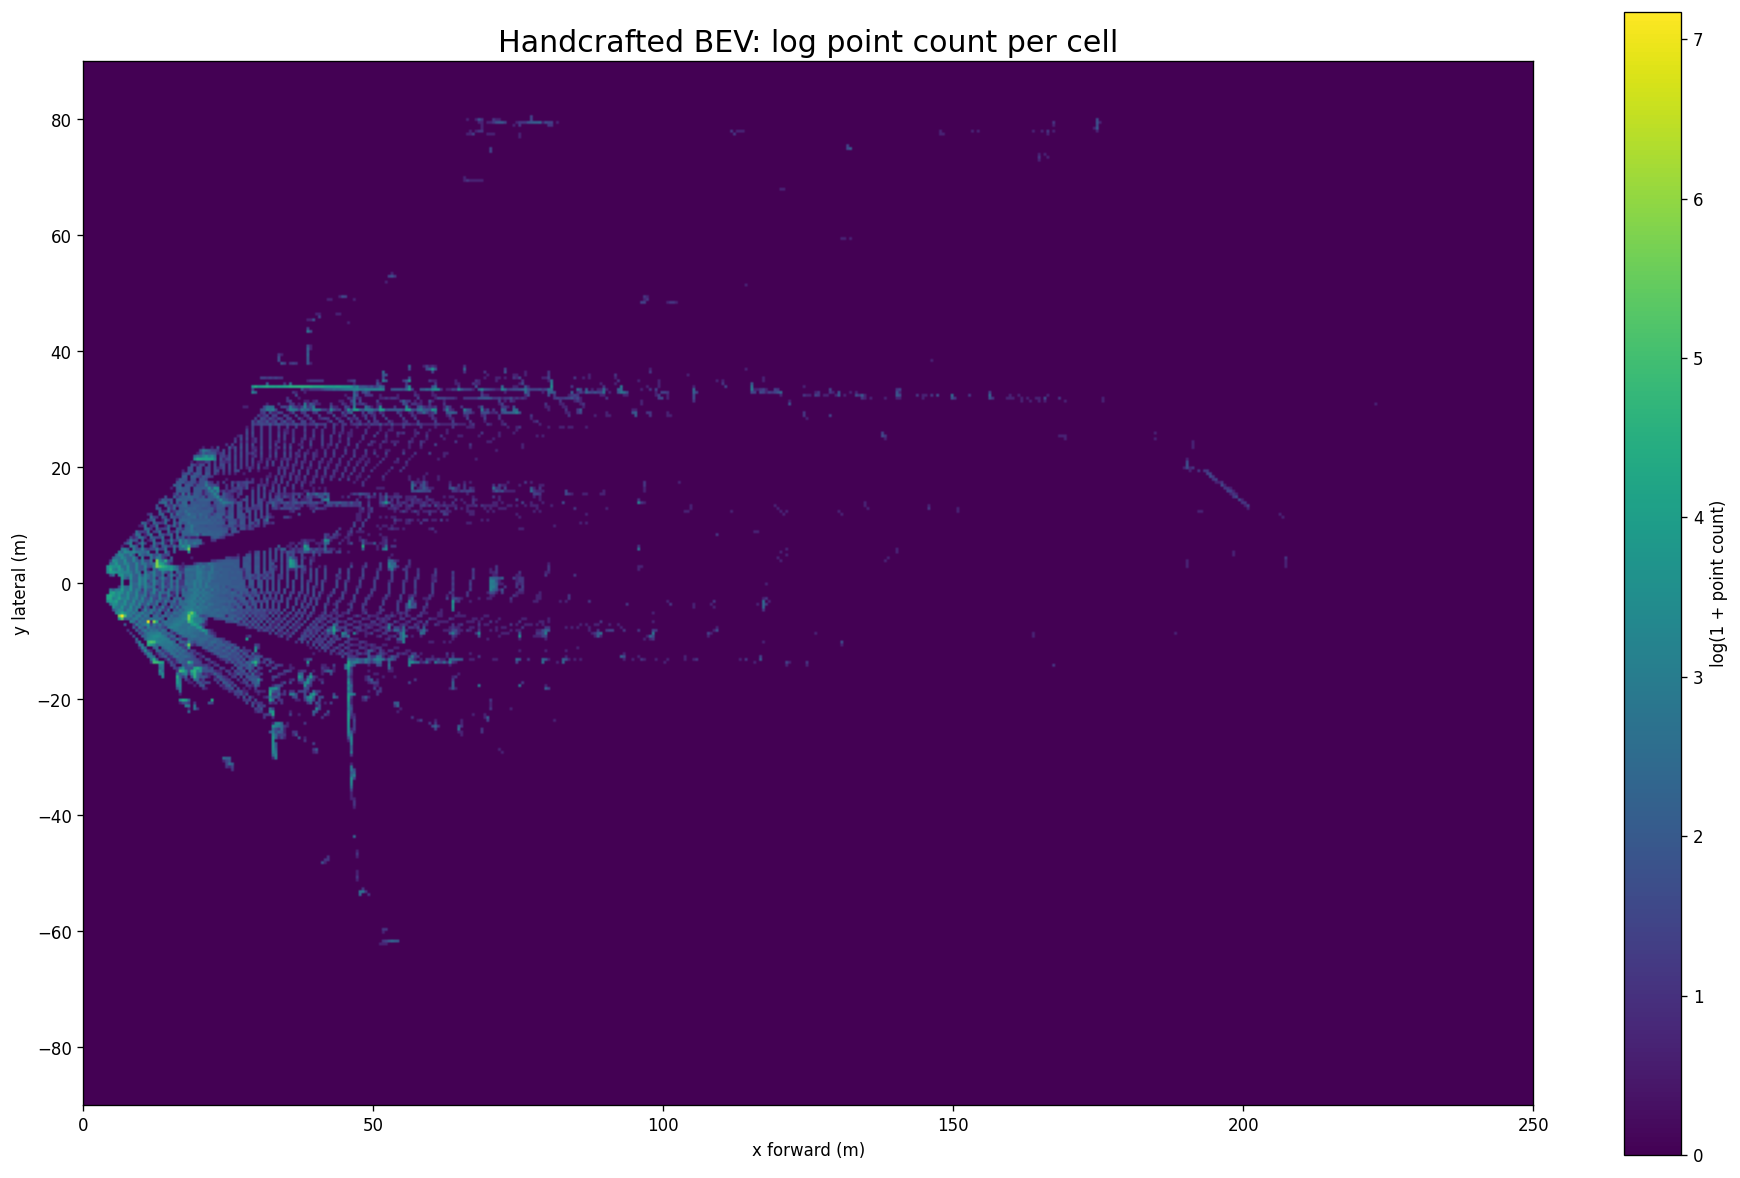

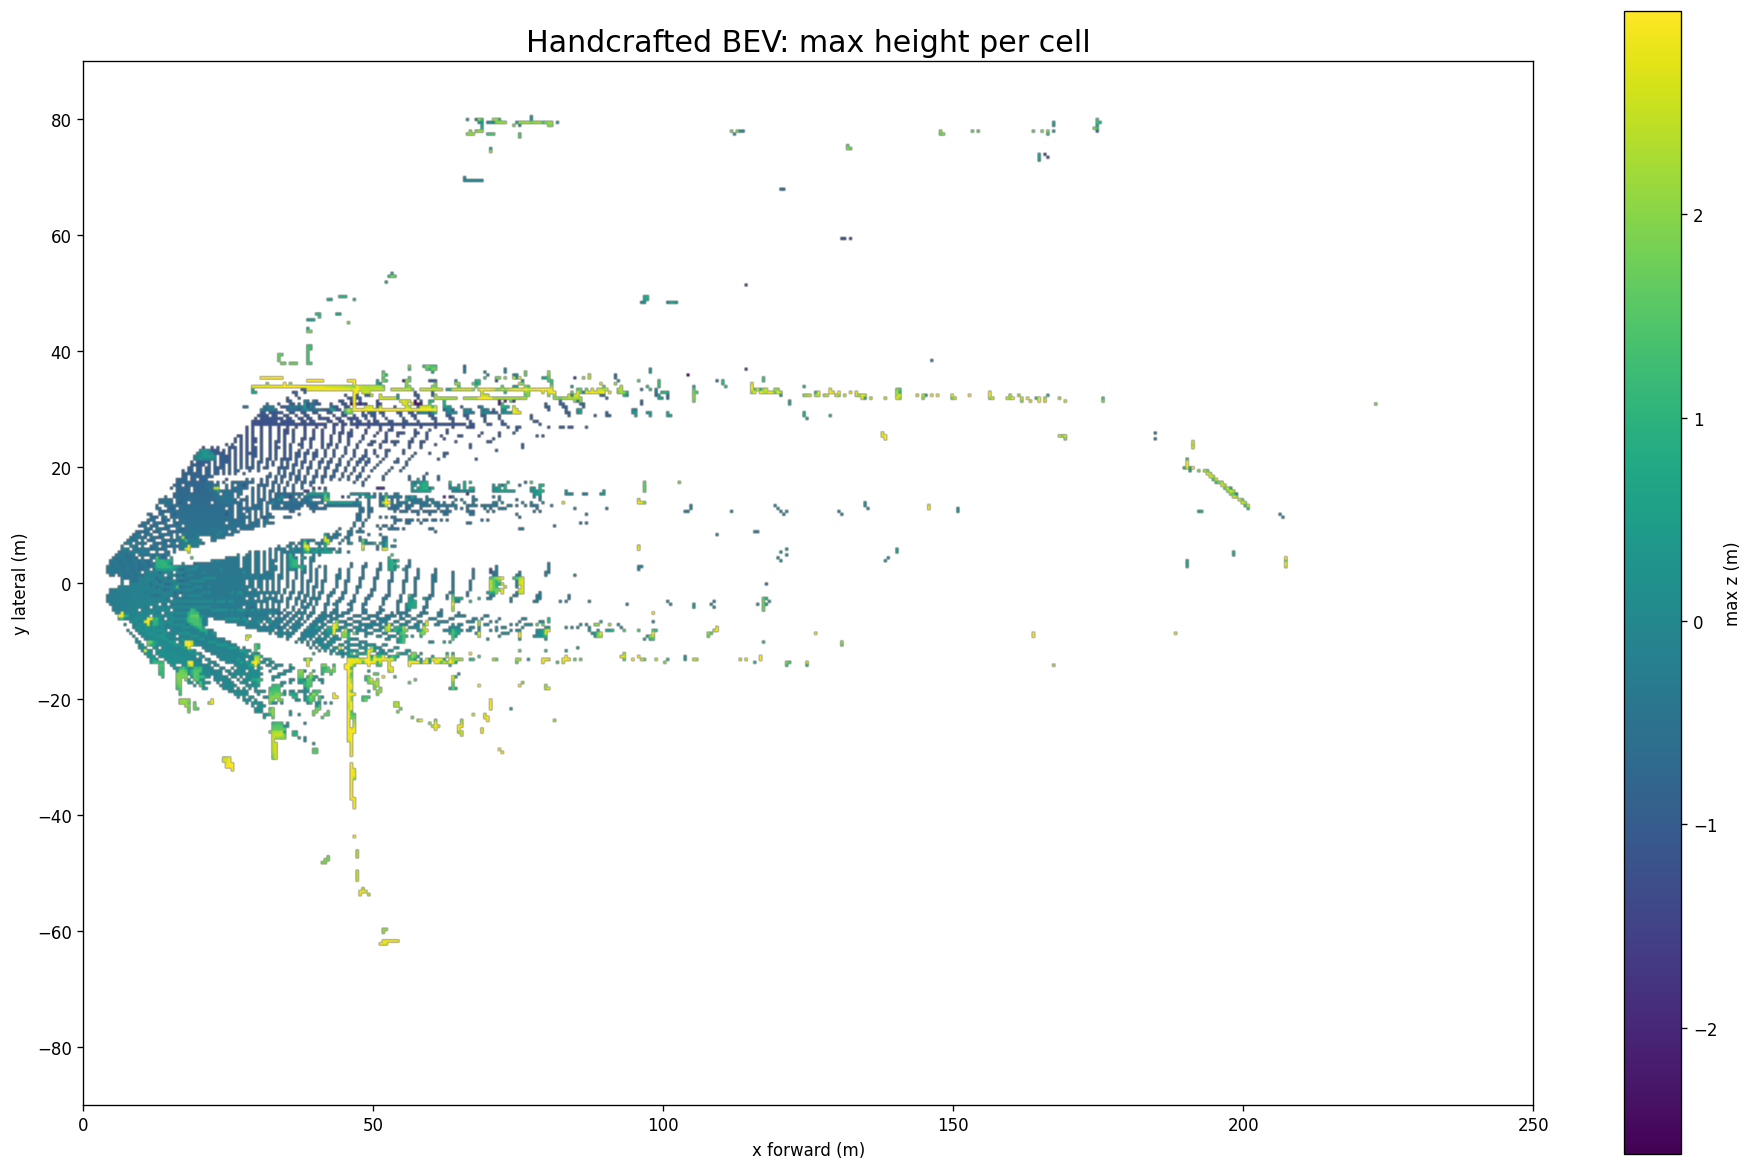

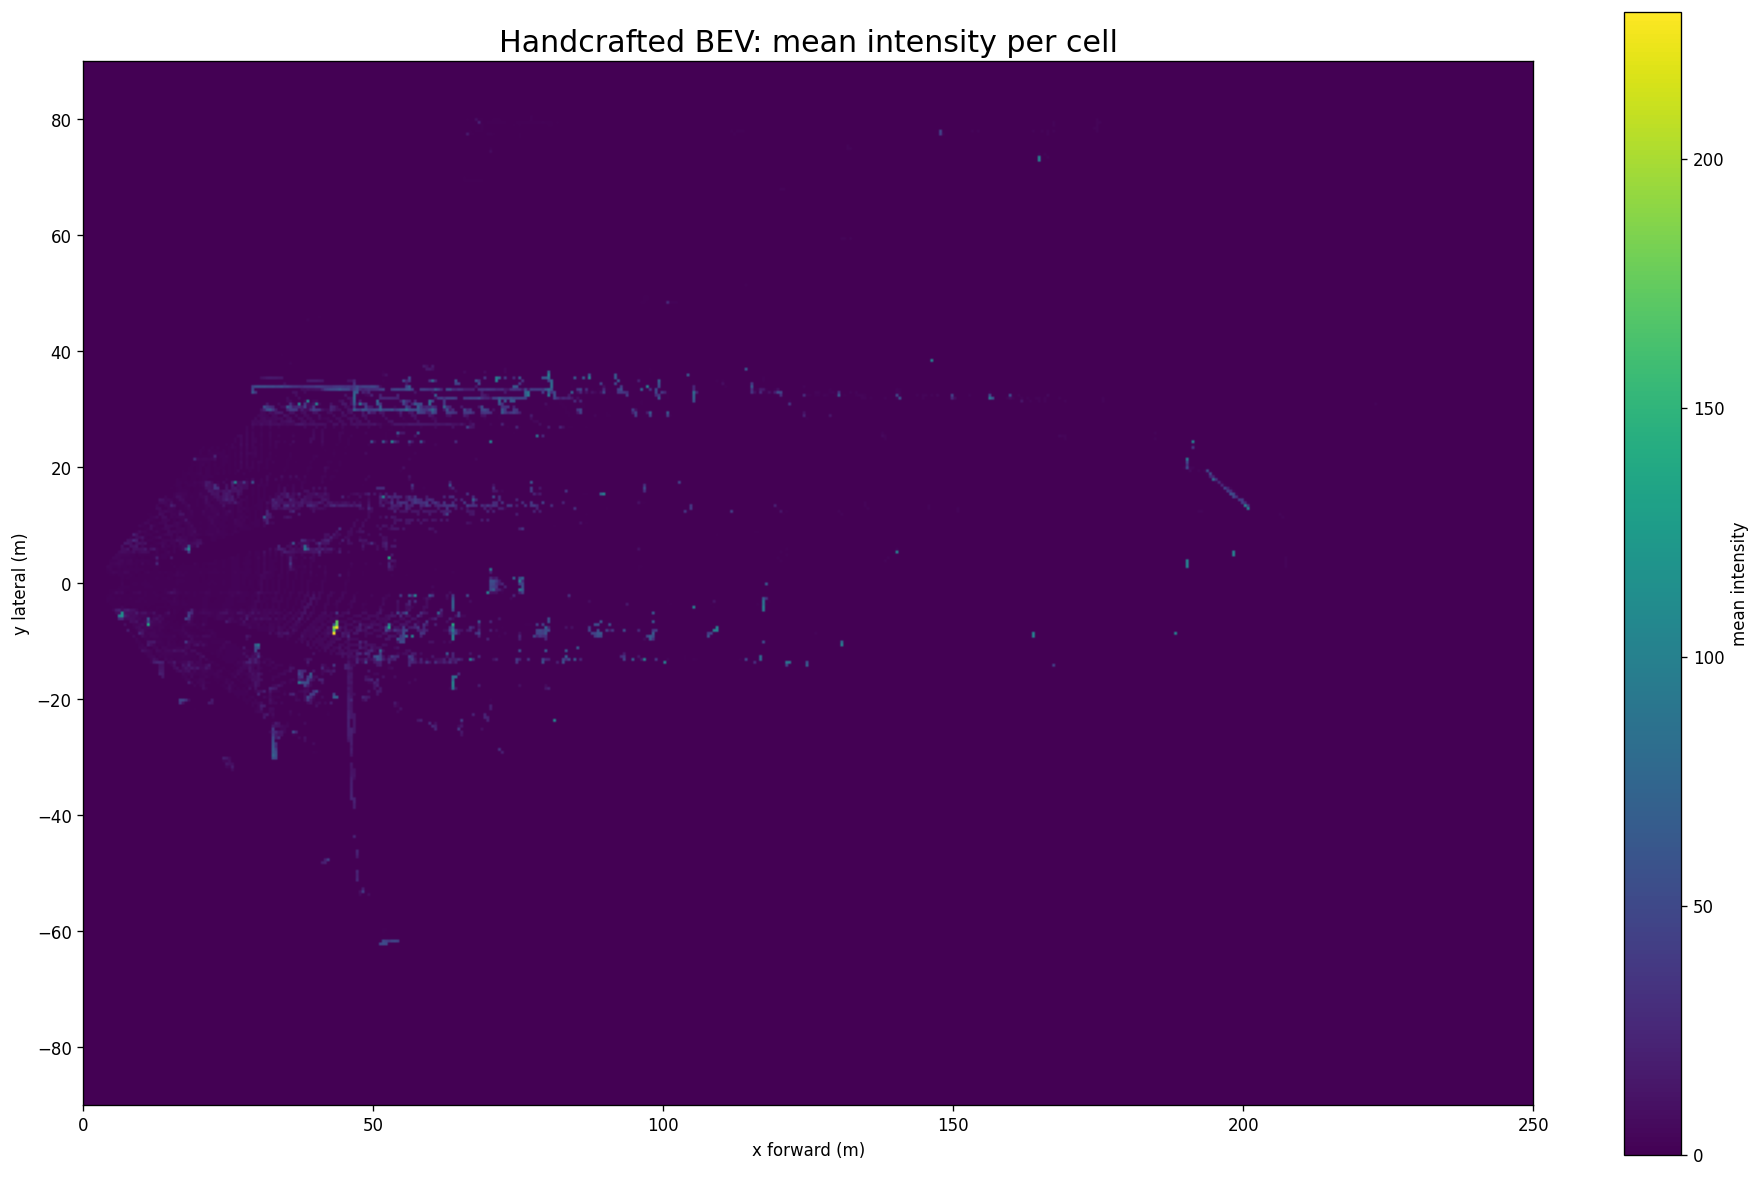

In [18]:
# ============================================================
# CELL C
# Visualize the handcrafted BEV maps
#
# IMPORTANT:
# These are human-interpretable maps.
# They are usually much easier to understand than learned
# PointPillars feature channels.
# ============================================================

extent = [X_MIN, X_MAX, Y_MIN, Y_MAX]

# ------------------------------------------------------------
# 1) Occupancy / log point count
# ------------------------------------------------------------
plt.figure(figsize=(16, 10), dpi=120)
plt.imshow(
    log_count_map,
    origin="lower",
    extent=extent,
    aspect="equal",
)
plt.title("Handcrafted BEV: log point count per cell", fontsize=18)
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar(label="log(1 + point count)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Maximum height per cell
# ------------------------------------------------------------
plt.figure(figsize=(16, 10), dpi=120)
plt.imshow(
    max_height_map,
    origin="lower",
    extent=extent,
    aspect="equal",
)
plt.title("Handcrafted BEV: max height per cell", fontsize=18)
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar(label="max z (m)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) Mean intensity per cell
# ------------------------------------------------------------
plt.figure(figsize=(16, 10), dpi=120)
plt.imshow(
    mean_intensity_map,
    origin="lower",
    extent=extent,
    aspect="equal",
)
plt.title("Handcrafted BEV: mean intensity per cell", fontsize=18)
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar(label="mean intensity")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Run the PointPillars FRONT-END on this single keyframe
#
# Pipeline:
#   points -> pillars -> pillar features -> BEV scatter
#
# What each stage does:
#
# 1) Voxelization
#    Groups points into vertical pillars on the BEV grid.
#
# 2) PillarFeatureNet
#    Turns all points inside each pillar into ONE learned feature
#    vector for that pillar.
#
# 3) PointPillarsScatter
#    Places those pillar feature vectors back onto a dense BEV
#    grid, producing a tensor of shape:
#
#       [batch_size, channels, NY, NX]
#
# This tensor is called a "pseudo-image" because a 2D CNN can
# process it like an image, even though it came from LiDAR.
# ============================================================

# ------------------------------------------------------------
# 1) Hard voxelization / pillarization
# ------------------------------------------------------------
voxel_layer = Voxelization(
    voxel_size=voxel_size,
    point_cloud_range=point_cloud_range,
    max_num_points=32,   # max points kept per pillar
    max_voxels=40000     # enough for one frame
)

# ------------------------------------------------------------
# 2) Pillar feature encoder
# ------------------------------------------------------------
# Input per point = [x, y, z, intensity]
# Output per occupied pillar = learned 64D feature vector
voxel_encoder = PillarFeatureNet(
    in_channels=4,
    feat_channels=[64],
    with_distance=False,
    voxel_size=voxel_size,
    point_cloud_range=point_cloud_range,
    legacy=False,
).to(device).eval()

# ------------------------------------------------------------
# 3) Scatter occupied pillar features back into BEV grid
# ------------------------------------------------------------
middle_encoder = PointPillarsScatter(
    in_channels=64,
    output_shape=[NY, NX],   # shape of final BEV grid
).to(device).eval()

with torch.no_grad():
    # --------------------------------------------------------
    # Step A: pillarize the points
    # --------------------------------------------------------
    # Typical outputs:
    #   voxels     : [num_pillars, max_num_points, 4]
    #   coors      : [num_pillars, ...]
    #   num_points : [num_pillars]
    voxels, coors, num_points = voxel_layer(points_tensor)

    print("voxels shape:", tuple(voxels.shape))
    print("coors shape:", tuple(coors.shape))
    print("num_points shape:", tuple(num_points.shape))

    # --------------------------------------------------------
    # Step B: ensure coordinates include batch index
    # --------------------------------------------------------
    # PointPillarsScatter expects coordinates like:
    #   [batch_idx, z_idx, y_idx, x_idx]
    #
    # Since we only have ONE frame in this notebook,
    # batch_idx = 0 for every occupied pillar.
    if coors.shape[1] == 3:
        batch_idx = torch.zeros(
            (coors.shape[0], 1),
            dtype=coors.dtype,
            device=coors.device
        )
        coors_batch = torch.cat([batch_idx, coors], dim=1)
    else:
        coors_batch = coors

    print("coors_batch shape:", tuple(coors_batch.shape))

    # --------------------------------------------------------
    # Step C: encode each occupied pillar into one feature vector
    # --------------------------------------------------------
    pillar_features = voxel_encoder(voxels, num_points, coors_batch)
    print("pillar_features shape:", tuple(pillar_features.shape))

    # --------------------------------------------------------
    # Step D: scatter pillar features into dense BEV tensor
    # --------------------------------------------------------
    bev_pseudoimage = middle_encoder(
        pillar_features,
        coors_batch,
        batch_size=1
    )

    print("bev_pseudoimage shape:", tuple(bev_pseudoimage.shape))

voxels shape: (6812, 32, 4)
coors shape: (6812, 3)
num_points shape: (6812,)
coors_batch shape: (6812, 4)
pillar_features shape: (6812, 64)
bev_pseudoimage shape: (1, 64, 360, 500)


Nonzero pillar cells: 6812
Max occupancy count in one BEV cell: 1.0


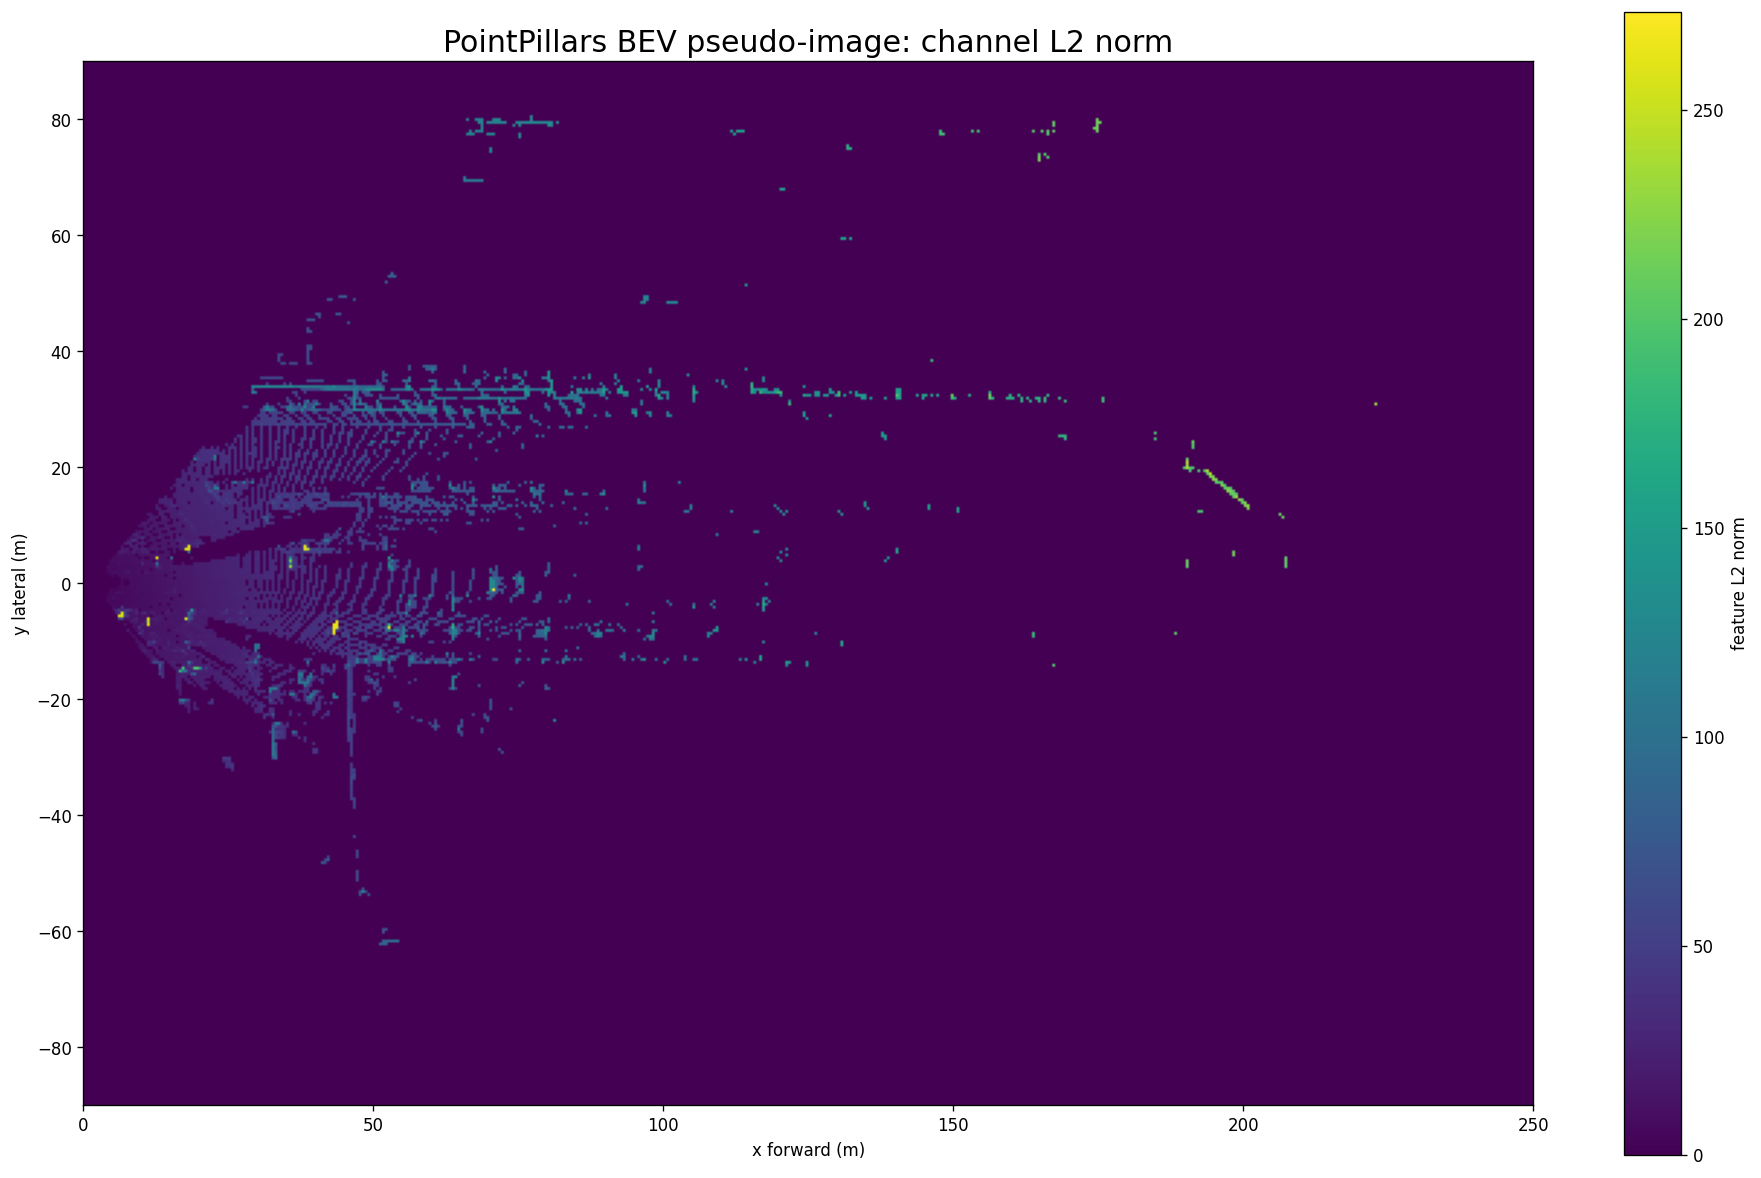

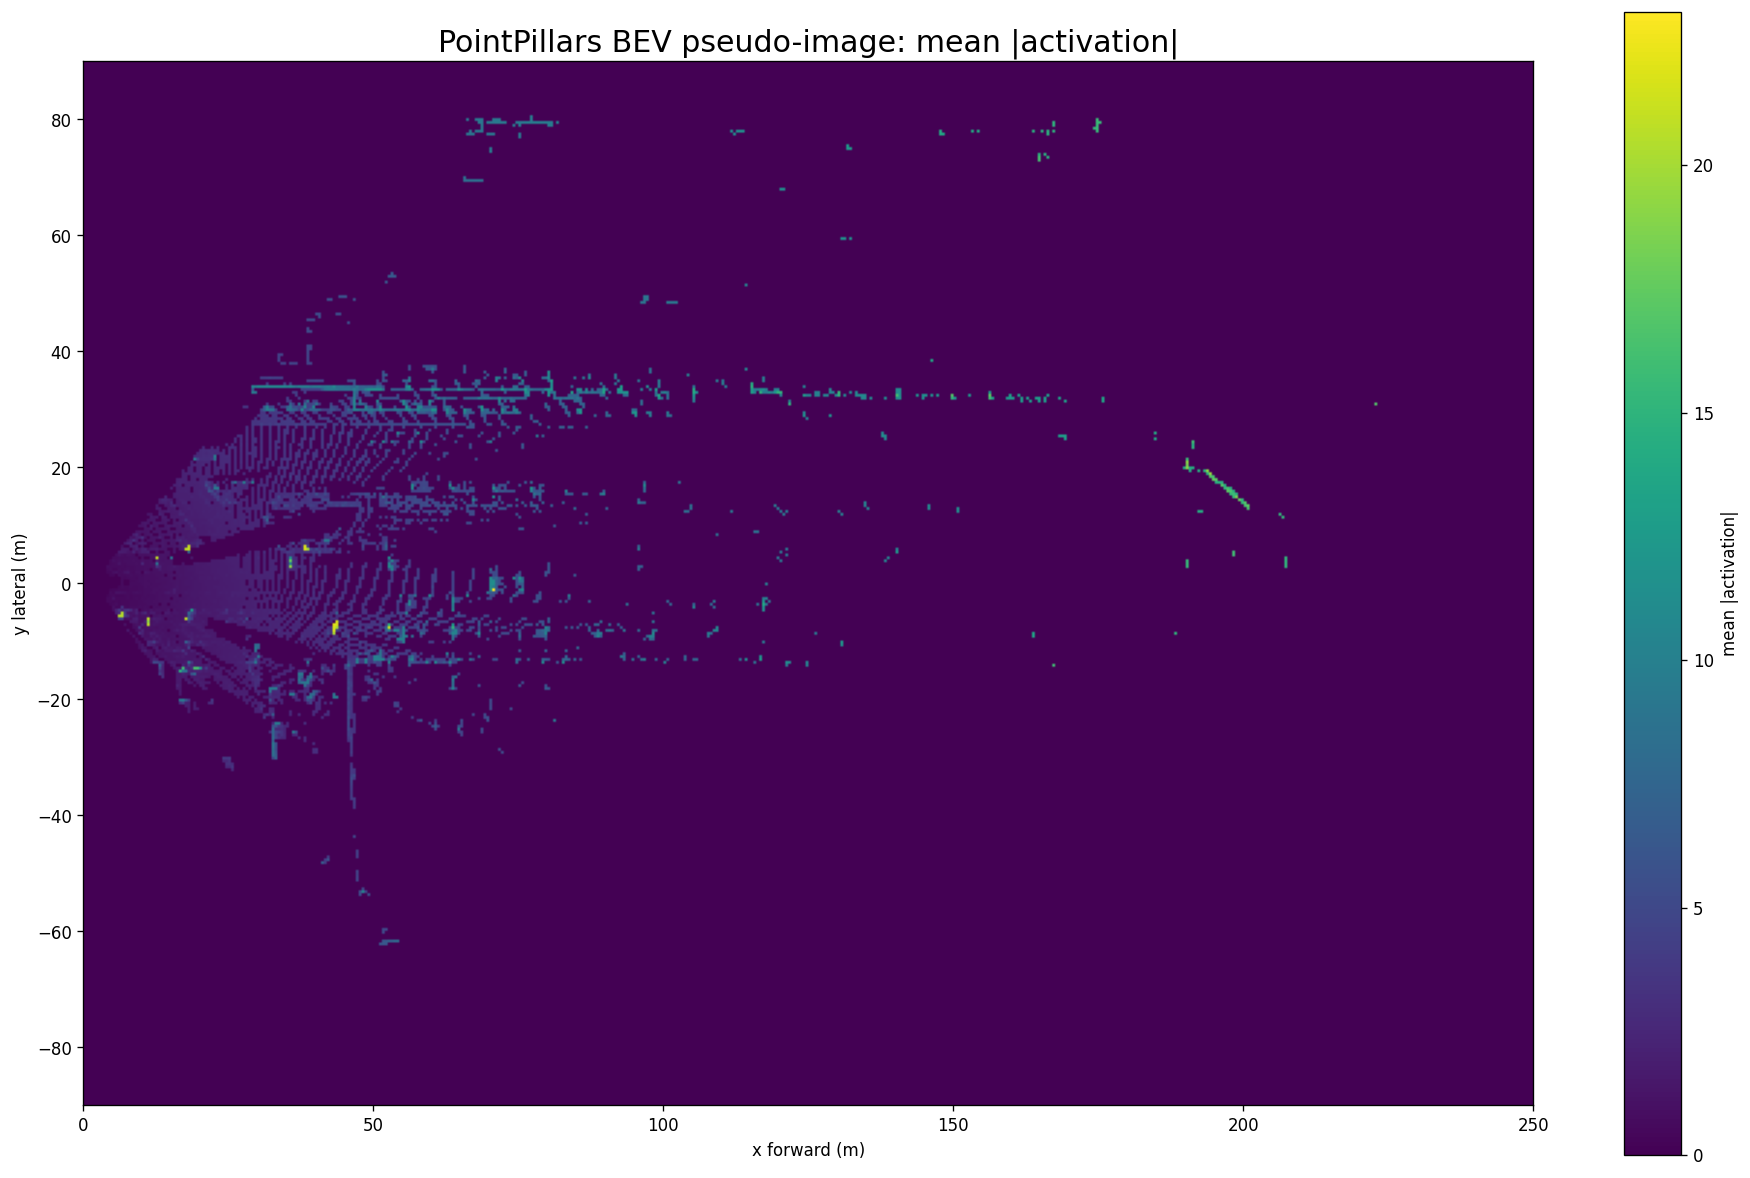

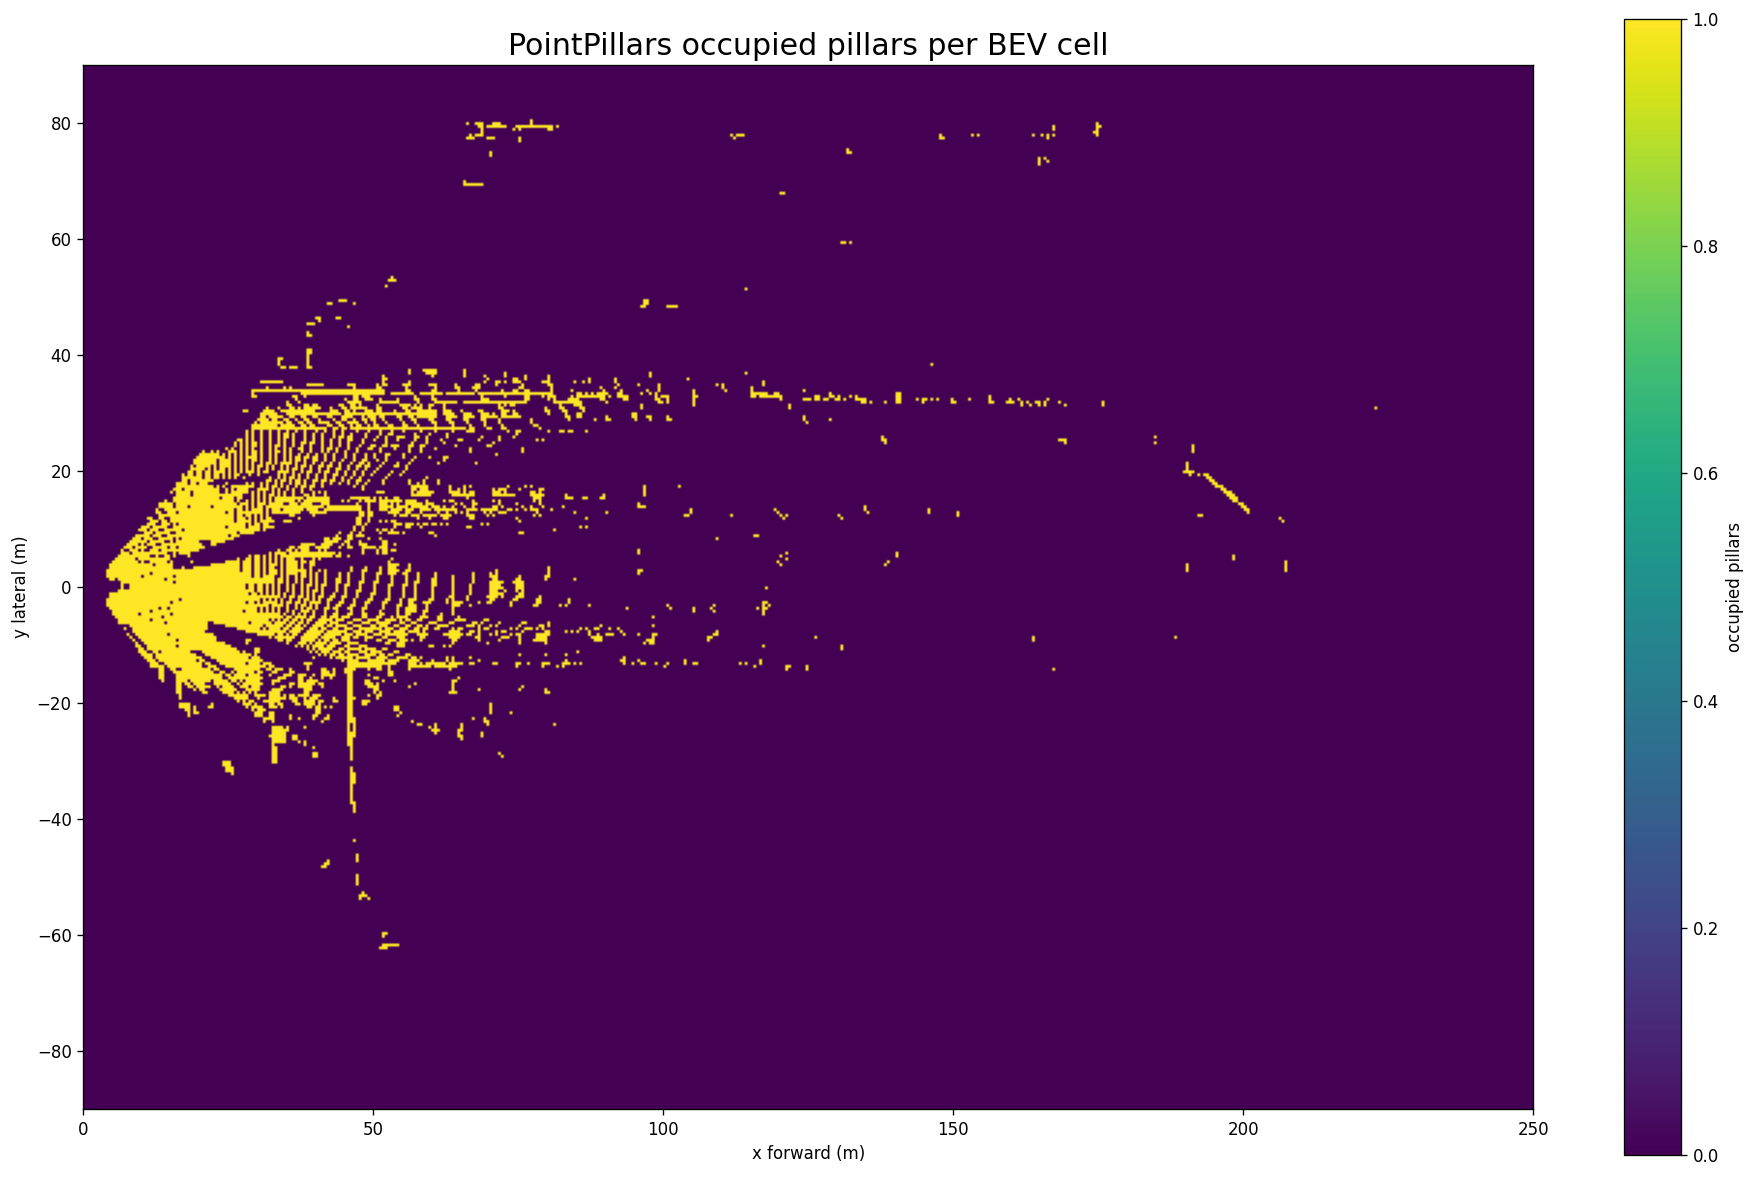

In [ ]:
# ============================================================
# Visualize the PointPillars BEV pseudo-image
#
# IMPORTANT:
# This is NOT directly an object map.
# It is a learned feature tensor.
#
# Each BEV cell contains a 64D learned feature vector, so to
# visualize it we need to collapse the channel dimension to
# one number per cell.
#
# We show:
#   1) channel L2 norm
#   2) mean absolute activation
#   3) occupied pillar count from coors_batch
#
# The third plot is especially useful because it is much more
# interpretable than the learned feature maps.
# ============================================================

# Remove batch dimension: [1, C, NY, NX] -> [C, NY, NX]
bev_cpu = bev_pseudoimage.detach().cpu()[0]

# ------------------------------------------------------------
# Collapse channels for visualization
# ------------------------------------------------------------
# 1) L2 norm across feature channels
bev_l2 = torch.norm(bev_cpu, dim=0).numpy()

# 2) Mean absolute activation across feature channels
bev_meanabs = bev_cpu.abs().mean(dim=0).numpy()

# ------------------------------------------------------------
# Build an interpretable occupancy-from-pillars map
# ------------------------------------------------------------
# coors_batch is typically [batch, z, y, x]
coors_np = coors_batch.detach().cpu().numpy()

pillar_occupancy_map = np.zeros((NY, NX), dtype=np.float32)

for row in coors_np:
    _, z_idx, y_idx, x_idx = row
    if 0 <= y_idx < NY and 0 <= x_idx < NX:
        pillar_occupancy_map[y_idx, x_idx] += 1.0

print("Nonzero pillar cells:", int(np.count_nonzero(pillar_occupancy_map)))
print("Max occupancy count in one BEV cell:", float(pillar_occupancy_map.max()))

extent = [X_MIN, X_MAX, Y_MIN, Y_MAX]

# ------------------------------------------------------------
# 1) Learned BEV feature magnitude: L2 norm
# ------------------------------------------------------------
plt.figure(figsize=(16, 10), dpi=120)
plt.imshow(
    bev_l2,
    origin="lower",
    extent=extent,
    aspect="equal",
)
plt.title("PointPillars BEV pseudo-image: channel L2 norm", fontsize=18)
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar(label="feature L2 norm")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Learned BEV feature magnitude: mean absolute activation
# ------------------------------------------------------------
plt.figure(figsize=(16, 10), dpi=120)
plt.imshow(
    bev_meanabs,
    origin="lower",
    extent=extent,
    aspect="equal",
)
plt.title("PointPillars BEV pseudo-image: mean |activation|", fontsize=18)
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar(label="mean |activation|")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) Interpretable occupied-pillar map
# ------------------------------------------------------------
plt.figure(figsize=(16, 10), dpi=120)
plt.imshow(
    pillar_occupancy_map,
    origin="lower",
    extent=extent,
    aspect="equal",
)
plt.title("PointPillars occupied pillars per BEV cell", fontsize=18)
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar(label="occupied pillars")
plt.tight_layout()
plt.show()